In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Visual Aesthetics
sns.set_theme(style="whitegrid")
%matplotlib inline

In [9]:
# Load Dataset
path = "https://raw.githubusercontent.com/AyushDiyundi/AI-Scientific-Programming/main/MedicalPremiumproject/Medicalpremium.csv"
df = pd.read_csv(path)

# 1. Remove Duplicates
df.drop_duplicates(inplace=True)

# 2. Check for Missing Values
print(f"\nMissing values check:\n{df.isnull().sum()}")

# 3. Feature Engineering: Calculate BMI
# BMI = weight(kg) / height(m)^2
df['BMI'] = (df['Weight'] / ((df['Height'] / 100) ** 2)).round(2)

print(f"\nCleaned Dataset Shape: {df.shape}")
df.head()


Missing values check:
Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

Cleaned Dataset Shape: (986, 12)


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI
0,45,0,0,0,0,155,57,0,0,0,25000,23.73
1,60,1,0,0,0,180,73,0,0,0,29000,22.53
2,36,1,1,0,0,158,59,0,0,1,23000,23.63
3,52,1,1,0,1,183,93,0,0,2,28000,27.77
4,38,0,0,0,1,166,88,0,0,1,23000,31.93


## **Research Hypotheses**
1. **Age Impact:** We hypothesize a strong positive correlation between `Age` and `PremiumPrice`.
2. **The Chronic Disease Gap:** Individuals with `AnyChronicDiseases` will face a significantly higher premium (The "Price Gap").
3. **BMI Significance:** Higher `BMI` will lead to increased insurance costs due to associated health risks.

## Exploratory Data Analysis (EDA)
We focus on identifying the "Price Gap" created by health risks and visualizing how premiums are distributed.

C:\Users\Ayush.Diyundi\AppData\Local\Temp\ipykernel_7432\629084528.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AnyChronicDiseases', y='PremiumPrice', data=df, palette='Set2')


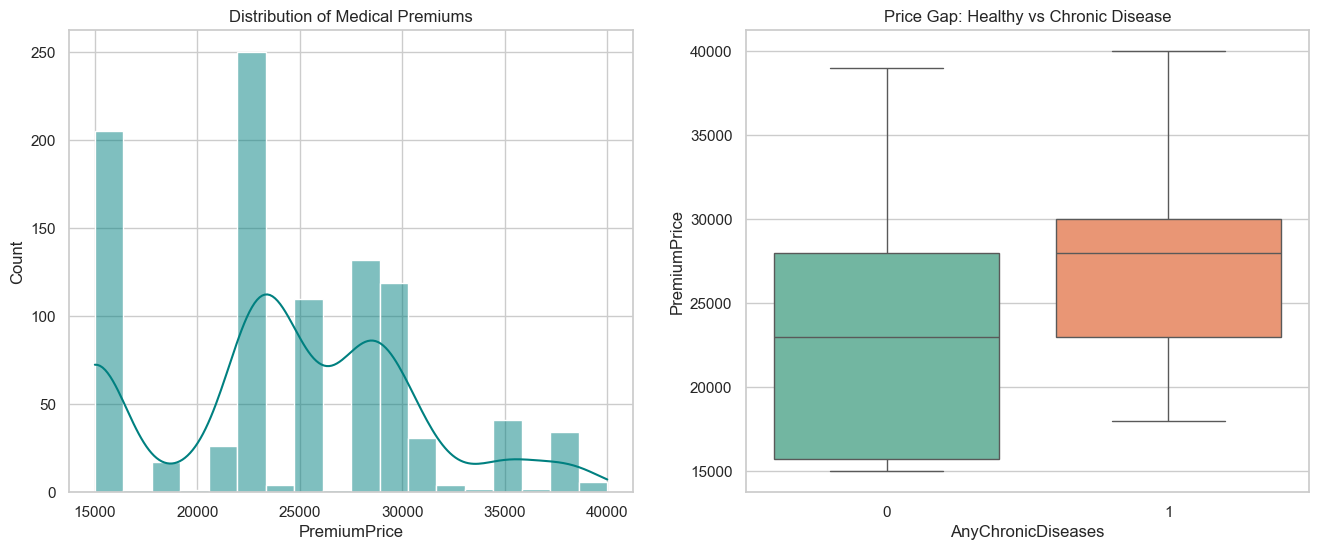

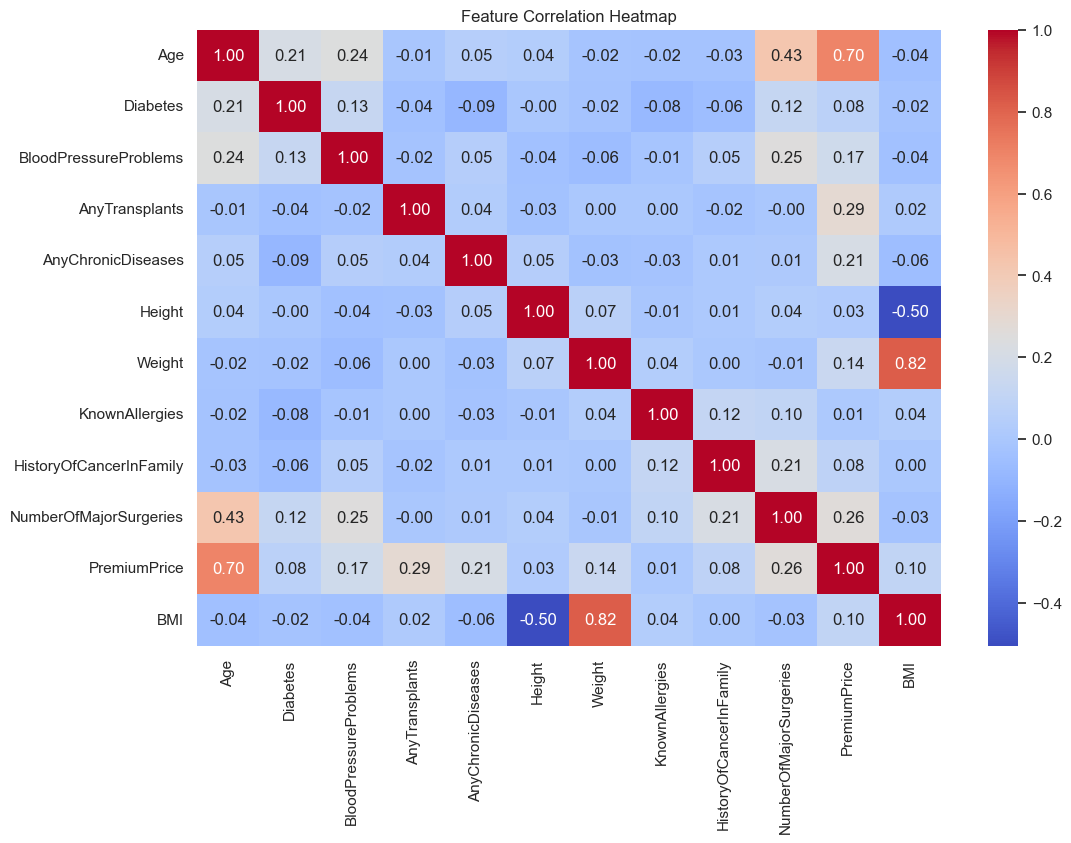

In [10]:
plt.figure(figsize=(16, 6))

# Plot 1: Distribution of Prices
plt.subplot(1, 2, 1)
sns.histplot(df['PremiumPrice'], kde=True, color='teal')
plt.title('Distribution of Medical Premiums')

# Plot 2: Testing Hypothesis 2 (The Price Gap)
# Requirement: Boxplot for risk gap analysis
plt.subplot(1, 2, 2)
sns.boxplot(x='AnyChronicDiseases', y='PremiumPrice', data=df, palette='Set2')
plt.title('Price Gap: Healthy vs Chronic Disease')

plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## **Machine Learning: Random Forest Regressor**
We use Random Forest because it handles the complex interactions between health factors (like Age + Chronic Disease + BMI) better than linear models.

In [11]:
# Define X and y
X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

# Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions & Metrics
preds = model.predict(X_test)
print(f"R-Squared Score: {r2_score(y_test, preds):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, preds):.2f}")

R-Squared Score: 0.8933
Mean Absolute Error: $1006.41


C:\Users\Ayush.Diyundi\AppData\Local\Temp\ipykernel_7432\2383080204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


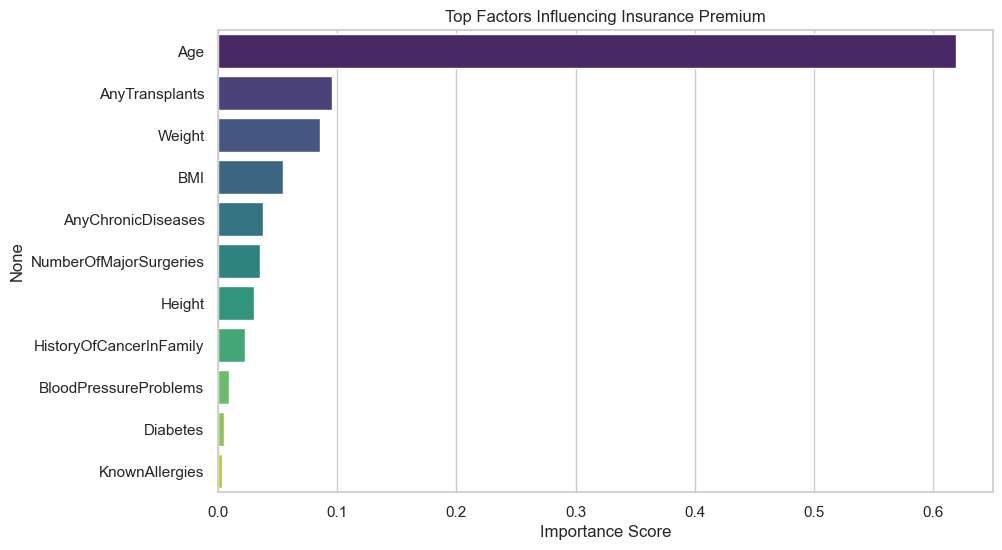

In [12]:
# Identify which health factors drive the price most
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Top Factors Influencing Insurance Premium')
plt.xlabel('Importance Score')
plt.show()

## **Deployment Preparation**
We save the model and the exact feature list as `.pkl` files. These files will be loaded by our Streamlit `app.py` to create the interactive Cost Calculator.

In [13]:
# Save model
joblib.dump(model, 'medical_premium_model.pkl')

# Save features to maintain correct order in the app
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ Model exported! You are now ready to run your Streamlit app.")

✅ Model exported! You are now ready to run your Streamlit app.
